In [7]:
import os

# Yahan apna dataset ka path daalo (Drive mein jahan folder rakha hai)
dataset_path = '/content/drive/MyDrive/Colab_Notebooks/Deep_Learning/CNN/Solar Panel Defect Classification/Data'

# Har class folder ka naam list karo
class_names = os.listdir(dataset_path)
print("Classes found:", class_names)

# Har class mein kitni images hain, ye count kar ke verify karte hain
# (taake pata chale hamara upar wala data count sahi match kar raha hai ya nahi)
for class_name in class_names:
    class_folder_path = os.path.join(dataset_path, class_name)

    # Sirf folders ko count karo, files ko skip karo
    if os.path.isdir(class_folder_path):
        image_files = os.listdir(class_folder_path)
        num_images = len(image_files)
        print(f"{class_name}: {num_images} images")

Classes found: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Snow-Covered', 'Physical-Damage']
Bird-drop: 193 images
Clean: 194 images
Dusty: 190 images
Electrical-damage: 103 images
Snow-Covered: 123 images
Physical-Damage: 69 images


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [9]:
!pip install split-folders

In [10]:
import os
import splitfolders

split_path = "/content/drive/MyDrive/Colab_Notebooks/Deep_Learning/CNN/Solar Panel Defect Classification/Split_Dataset"

if not os.path.exists(split_path):
    splitfolders.ratio(
        dataset_path,
        output=split_path,
        seed=42,
        ratio=(0.7, 0.15, 0.15)
    )
    print("Dataset split Done.")
else:
    print("Split dataset already available.")

Split dataset already available.


In [11]:
# ============================================
# IMPORTS
# ============================================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ============================================
# DATA LOADING (fresh load, koi rescaling nahi - EfficientNet khud handle karta hai)
# ============================================

import tensorflow as tf

split_dataset_path = "/content/drive/MyDrive/Colab_Notebooks/Deep_Learning/CNN/Solar Panel Defect Classification/Split_Dataset"

train_path = split_dataset_path + "/train"
val_path = split_dataset_path + "/val"
test_path = split_dataset_path + "/test"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=32,
    seed=123
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224,224),
    batch_size=32,
    seed=123
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    seed=123
)

class_names = train_dataset.class_names
print(class_names)

# Yahan koi Rescaling(1./255) ya preprocess_input NAHI lagana
# EfficientNetB0 ke andar Rescaling + Normalization layers already built-in hain

# Performance optimization - cache/shuffle/prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# ============================================
# DATA AUGMENTATION (same jo pehle use kiya tha)
# ============================================

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# ============================================
# EARLY STOPPING (dono phases mein reuse hoga)
# ============================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# ============================================
# PHASE 1: EfficientNetB0 base frozen, sirf naya head train
# ============================================

base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Phase 1: base completely frozen rakho
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

checkpoint_phase1 = ModelCheckpoint(
    'best_model_efficientnetb0_phase1.keras',
    monitor='val_loss',
    save_best_only=True
)




Found 607 files belonging to 6 classes.
Found 127 files belonging to 6 classes.
Found 135 files belonging to 6 classes.
['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
print("\n===== PHASE 1: Training with frozen base =====\n")

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stop, checkpoint_phase1]
)



===== PHASE 1: Training with frozen base =====

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.4415 - loss: 1.4058 - val_accuracy: 0.6063 - val_loss: 1.0308
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.6606 - loss: 0.9233 - val_accuracy: 0.6850 - val_loss: 0.8078
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.7414 - loss: 0.7213 - val_accuracy: 0.7244 - val_loss: 0.7295
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.7677 - loss: 0.6406 - val_accuracy: 0.7323 - val_loss: 0.6874
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8204 - loss: 0.5307 - val_accuracy: 0.7480 - val_loss: 0.6354
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.8484 - loss: 0.4789 - val_accuracy: 0.7638 - val_loss: 0.6387
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.8353 - loss: 0.4684 - val_accuracy: 0.7559 - val_loss: 0.5740
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accu

In [13]:
# ============================================
# PHASE 2: Fine-tuning (top layers unfreeze, BatchNorm frozen rakho)
# ============================================

# Total layers dekhte hain pehle
print("\nTotal layers in EfficientNetB0 base:", len(base_model.layers))

base_model.trainable = True

# EfficientNetB0 mein MobileNetV2 se zyada layers hote hain (~237)
# Top ~20-30% unfreeze karna common practice hai
fine_tune_at = 150   # ye number total layers dekh ke adjust kar sakte ho

# Is index se pehle wali layers freeze rakho
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# CRITICAL FIX: BatchNorm layers hamesha frozen rakho, chahe unfrozen part mein hi kyun na hon
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile - bohot low learning rate ke saath
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_phase2 = ModelCheckpoint(
    'best_model_efficientnetb0_finetuned.keras',
    monitor='val_loss',
    save_best_only=True
)

print("\n===== PHASE 2: Fine-tuning =====\n")

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stop, checkpoint_phase2]
)

# ============================================
# EVALUATION - best fine-tuned model load karo aur test karo
# ============================================

best_model_efficientnet = tf.keras.models.load_model('best_model_efficientnetb0_finetuned.keras')

val_loss, val_accuracy = best_model_efficientnet.evaluate(val_dataset)
print(f"\nFine-tuned EfficientNetB0 -> Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = best_model_efficientnet.evaluate(test_dataset)
print(f"Fine-tuned EfficientNetB0 -> Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Total layers in EfficientNetB0 base: 238

===== PHASE 2: Fine-tuning =====

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 429ms/step - accuracy: 0.8880 - loss: 0.3555 - val_accuracy: 0.7559 - val_loss: 0.5770
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.8946 - loss: 0.3318 - val_accuracy: 0.7559 - val_loss: 0.5547
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.9012 - loss: 0.3189 - val_accuracy: 0.7638 - val_loss: 0.5460
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.9012 - loss: 0.3135 - val_accuracy: 0.7559 - val_loss: 0.5535
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step - accuracy: 0.8995 - loss: 0.2926 - val_accuracy: 0.7717 - val_loss: 0.5331
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 187ms/step - accuracy: 0.9077 - loss: 0.2782 - val_accuracy: 0.7717 - val_loss: 0.5360
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.9275 - loss: 0.2639 - val_accuracy: 0.7638 - val_loss: 0.5246
Epoch 8/30
19/19 ━━━━━━━━━

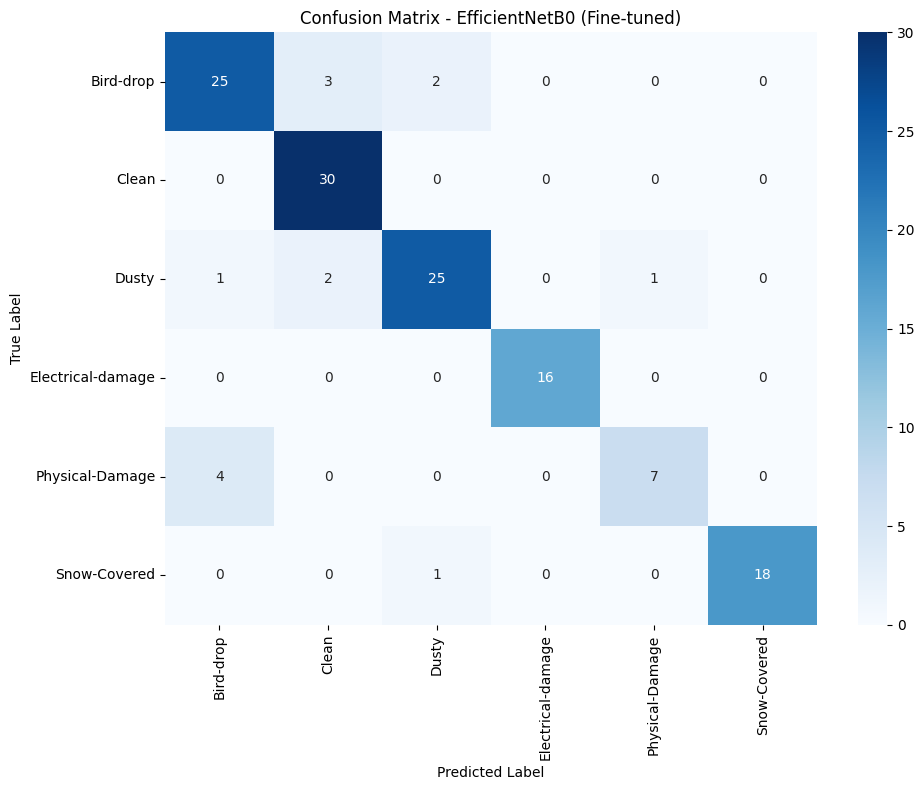


Classification Report:

                   precision    recall  f1-score   support

        Bird-drop       0.83      0.83      0.83        30
            Clean       0.86      1.00      0.92        30
            Dusty       0.89      0.86      0.88        29
Electrical-damage       1.00      1.00      1.00        16
  Physical-Damage       0.88      0.64      0.74        11
     Snow-Covered       1.00      0.95      0.97        19

         accuracy                           0.90       135
        macro avg       0.91      0.88      0.89       135
     weighted avg       0.90      0.90      0.89       135



In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Best model se test set pe predictions nikalo
y_true = []
y_pred = []

# test_dataset se batch by batch images aur true labels nikalo
for images, labels in test_dataset:
    predictions = best_model_efficientnet.predict(images, verbose=0)

    # Softmax output mein se highest probability wali class ka index lo
    predicted_classes = np.argmax(predictions, axis=1)

    # True labels aur predicted labels ko list mein add karte jao
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

# Confusion matrix calculate karo
cm = confusion_matrix(y_true, y_pred)

# Plot karo - heatmap ke saath, taake easily samajh aaye
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # numbers dikhao har cell mein
    fmt='d',             # integer format
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - EfficientNetB0 (Fine-tuned)')
plt.tight_layout()
plt.show()

# Detailed per-class report bhi nikalo - precision, recall, f1-score
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [15]:
import json

# class_names ko file mein save karo (order important hai!)
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

# Download kar lo
from google.colab import files
files.download('class_names.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)

2.20.0
3.13.2
